# Pytorch and Numpy

## Import

In [2]:
import numpy as np
import torch

## Pytorch basics

In [4]:
a = torch.tensor([1, 4, 6, 7])
a = torch.zeros(10)
a = torch.arange(10, dtype=torch.float32)
print(a)

a = torch.rand((10, 2))
a.sum(dim=1)

tensor([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])


tensor([1.4216, 0.9573, 1.1392, 1.4677, 0.4950, 0.7465, 0.9687, 0.3712, 1.4276,
        0.8239])

### Pytorch devices

In [10]:
print(a.device)
# a_cuda = torch.arange(10, device="cuda:0")
# print(a_cuda.device)
# a.to('cuda:0', dtype=bool)

cpu


### Pytorch gradient calculation

In [13]:
x = torch.tensor([2.0], requires_grad=True)
y = torch.log(x)

gradient = torch.autograd.grad(y, x)

print("Original: ", x.item())
print("Gradient: ", gradient[0].item())
print(gradient)
print(y)

Original:  2.0
Gradient:  0.5
(tensor([0.5000]),)
tensor([0.6931], grad_fn=<LogBackward0>)


### Pytorch basic layer connections

In [15]:
import torch.nn as nn

x = torch.rand(32, 4)
linear_layer = nn.Linear(4, 8, bias=True, device='cpu')
y = linear_layer(x)

w = torch.rand((4+1, 8), device='cpu', requires_grad=True) # +1 the bias
x = torch.cat([x, torch.ones((32, 1))], dim=-1)
y = x @ w

print(x)
print(w)
print(y)

tensor([[0.2580, 0.4814, 0.7310, 0.8905, 1.0000],
        [0.0937, 0.7544, 0.0289, 0.7666, 1.0000],
        [0.0331, 0.8728, 0.4867, 0.9951, 1.0000],
        [0.1822, 0.2552, 0.8752, 0.5557, 1.0000],
        [0.9009, 0.3557, 0.3812, 0.3250, 1.0000],
        [0.4608, 0.7022, 0.0570, 0.3511, 1.0000],
        [0.0680, 0.4239, 0.0873, 0.2075, 1.0000],
        [0.6658, 0.1430, 0.0862, 0.9412, 1.0000],
        [0.7048, 0.4330, 0.1884, 0.8412, 1.0000],
        [0.7329, 0.7538, 0.2554, 0.8441, 1.0000],
        [0.0490, 0.7982, 0.6694, 0.6796, 1.0000],
        [0.4781, 0.7709, 0.1758, 0.3854, 1.0000],
        [0.5252, 0.8167, 0.3435, 0.5972, 1.0000],
        [0.1062, 0.0584, 0.7943, 0.6459, 1.0000],
        [0.9333, 0.4209, 0.7104, 0.5308, 1.0000],
        [0.7966, 0.6035, 0.5180, 0.5531, 1.0000],
        [0.3439, 0.2204, 0.8630, 0.3240, 1.0000],
        [0.1842, 0.6799, 0.5434, 0.3533, 1.0000],
        [0.2436, 0.8819, 0.2467, 0.5531, 1.0000],
        [0.9685, 0.8214, 0.7629, 0.0844, 1.0000],


## Model + Learn

### Import data

In [18]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing()
features = pd.DataFrame(housing.data, columns=housing.feature_names)

target = pd.DataFrame(housing.target, columns=['MEDV'])

print(features.head())
print(target.head())
print(features.describe())
print(target.describe())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
    MEDV
0  4.526
1  3.585
2  3.521
3  3.413
4  3.422
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25% 

### Split data to training set, test set and validation set

In [19]:
from sklearn.model_selection import train_test_split

x_train, x_rest, y_train, y_rest = train_test_split(features.values, target.values, train_size=0.7, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_rest, y_rest, train_size=0.5, random_state=42)

In [20]:
from torch.utils.data import Dataset, DataLoader

class HousingDataset(Dataset):
    def __init__(self, features, target):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.target = torch.tensor(target, dtype=torch.float32)

    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        return self.features[index], self.target[index]
    
train_dataset = HousingDataset(x_train, y_train)
val_dataset = HousingDataset(x_test, y_test)
test_dataset = HousingDataset(x_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True)

print(train_dataset[10])

(tensor([ 1.5086e+00,  1.2000e+01,  3.9837e+00,  9.7003e-01,  1.7080e+03,
         4.6540e+00,  3.6210e+01, -1.2010e+02]), tensor([0.6470]))


### Create model with layers

In [21]:
class RegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear_relu_layers = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )
    
    def forward(self, x):
        return self.linear_relu_layers(x)

### Training + Validation

In [22]:
n_epochs = 20 # Number of epoch
model = RegressionModel(8) # Our model with 8 input features (8 columns in the input data)
loss_fn = nn.MSELoss() # Loss function

learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) # Optimizer

train_losses = []
val_losses = []

for epoch in range(n_epochs):
    model.train() # Toggle train mode
    train_epoch_losses = []

    for x, y in train_dataloader: # input features (x), label (y)
        optimizer.zero_grad() # Null all gradient
        y_hat = model(x) # Run model
        loss = loss_fn(y_hat, y) # Calculate loss from actual y and expected y
        train_epoch_losses.append(loss) # Save epoc loss
        loss.backward() # Calculate gradient backward
        optimizer.step() # Optimize weights
    
    train_epoch_losses = torch.tensor(train_epoch_losses)
    avg_epoch_loss = train_epoch_losses.mean()
    train_losses.append(avg_epoch_loss)

    model.eval() # Evaluate the performance of our model (toggle mode from train)

    val_epoch_losses = []

    for x, y in val_dataloader:
        with torch.no_grad(): # Specific environment: No need to calculate the gradients
            y_hat = model(x)
        
        loss = loss_fn(y_hat, y)
        val_epoch_losses.append(loss)

    val_epoch_losses = torch.tensor(val_epoch_losses)
    avg_epoch_loss = val_epoch_losses.mean()
    val_losses.append(avg_epoch_loss)

    print(f'Training {epoch+1}/{n_epochs} done, training loss: {train_losses[-1]}, validation loss: {val_losses[-1]}')


Training 1/20 done, training loss: 16.317506790161133, validation loss: 2.2459142208099365
Training 2/20 done, training loss: 1.6303212642669678, validation loss: 1.2970924377441406
Training 3/20 done, training loss: 1.2191473245620728, validation loss: 1.089737057685852
Training 4/20 done, training loss: 1.0040528774261475, validation loss: 0.8281355500221252
Training 5/20 done, training loss: 0.8124274015426636, validation loss: 0.8469168543815613
Training 6/20 done, training loss: 0.7768427729606628, validation loss: 0.6958761811256409
Training 7/20 done, training loss: 0.6954889297485352, validation loss: 0.6488456130027771
Training 8/20 done, training loss: 0.6377643942832947, validation loss: 0.7175625562667847
Training 9/20 done, training loss: 0.6207848787307739, validation loss: 0.6080758571624756
Training 10/20 done, training loss: 0.855266809463501, validation loss: 0.5821009278297424
Training 11/20 done, training loss: 0.6186352968215942, validation loss: 0.7267950177192688

#### Display train results

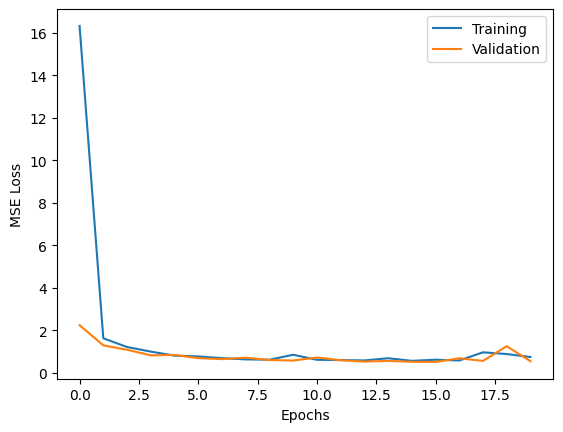

In [23]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training')
plt.plot(val_losses, label='Validation')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

### Run test

In [24]:
model.eval()
test_losses = []
predicition_label_pairs = []

for x, y in test_dataloader:
    with torch.no_grad():
        y_hat = model(x)
    
    loss = loss_fn(y_hat, y)
    predicition_label_pairs.append(torch.concat((y_hat, y), dim=-1))
    test_losses.append(loss)

avg_test_loss = torch.tensor(test_losses).mean()
print('Average loss on the test dataset: ', avg_test_loss.item())
print(predicition_label_pairs[0])

Average loss on the test dataset:  0.5533716082572937
tensor([[1.6530, 0.9010],
        [1.5283, 0.9130],
        [1.5283, 1.5060],
        [1.6531, 2.0000],
        [1.5283, 0.6890],
        [1.8688, 0.8930],
        [1.5283, 1.9950],
        [2.1514, 1.4710],
        [1.6024, 1.8840],
        [2.9940, 3.9550],
        [2.8880, 2.2590],
        [1.5283, 0.9250],
        [1.5283, 0.7940],
        [2.1214, 1.1270],
        [2.3082, 4.2500],
        [2.6635, 1.7190]])


### Save model

In [25]:
model_path = 'model.pth'
torch.save(model.state_dict(), model_path)
model = torch.load(model_path)